# B"H
# Final Project in Medical Imaging
## ML Implementation

---
### Supervisor: Dr. Eyal Ben-Issac
### Students: Lior Cohen & Tomer Peretz
### Date: 20.07.2025

# Loading

In [44]:
import os
import cv2
import random
import shutil
import joblib
import warnings
import numpy as np
import pandas as pd
from PIL import Image
import seaborn as sns
import tensorflow as tf
from sklearn.svm import SVC
from google.colab import auth
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
from sklearn.metrics import accuracy_score
from tensorflow.keras import layers, models
from sklearn.ensemble import VotingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import LabelEncoder
from oauth2client.client import GoogleCredentials
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
warnings.filterwarnings("ignore")

## Fetching

> Loading the images from Google Drive

*   We started with a publicly accessible folder in Google Drive containing subfolders of images.
*   Using the pydrive library, we authenticated and accessed the folder and its contents programmatically.







In [2]:
# Authenticate and create the PyDrive client
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)


folder_id = '19sZid9MtP40UcVuFlmFAfuFx7P49MxkK'
file_list = drive.ListFile({'q': f"'{folder_id}' in parents and trashed=false"}).GetList()

for file in file_list:
    print(f"Title: {file['title']}, ID: {file['id']}")

Title: 01, ID: 1ymtm84uqm8nLAH_YSxMmjjRznO2LVUKs
Title: 03, ID: 1t2yWUtnGU5Z7zN6xZa6rFoX89fgc1oC1
Title: 02, ID: 1n6vq7zH7CiyTbcpl4YCkR7th5-4_xs1e


> Deleting folders in Google Drive's local temp folder

In [3]:
try:
  shutil.rmtree("/content/sample_data")
except FileNotFoundError:
  print("The directory alrealy removed")

> Loading the images and saves them in local Drive folder

**It takes about 5 minutes to load**

In [4]:
base_dir = '/content/dataset'
os.makedirs(base_dir, exist_ok=True)

# Download files and maintain folder structure
for file in file_list:
    if file['mimeType'] == 'application/vnd.google-apps.folder':  # If it's a folder
        subfolder_name = file['title']
        subfolder_id = file['id']
        subfolder_path = os.path.join(base_dir, subfolder_name)
        os.makedirs(subfolder_path, exist_ok=True)
        subfolder_files = drive.ListFile({'q': f"'{subfolder_id}' in parents and trashed=false"}).GetList()

        # Download images into the subfolder
        for subfile in subfolder_files:
            if subfile['mimeType'].startswith('image/'):  # If it's an image
                subfile.GetContentFile(os.path.join(subfolder_path, subfile['title']))
                print(f"Downloaded {subfile['title']} to {subfolder_path}")
    elif file['mimeType'].startswith('image/'):  # If it's an image directly in the main folder
        file.GetContentFile(os.path.join(base_dir, file['title']))
        print(f"Downloaded {file['title']} to {base_dir}")

Downloaded 084.jpeg to /content/dataset/01
Downloaded 052.jpeg to /content/dataset/01
Downloaded 053.jpeg to /content/dataset/01
Downloaded 075.jpeg to /content/dataset/01
Downloaded 081.jpeg to /content/dataset/01
Downloaded 074.jpeg to /content/dataset/01
Downloaded 082.jpeg to /content/dataset/01
Downloaded 064.jpeg to /content/dataset/01
Downloaded 061.jpeg to /content/dataset/01
Downloaded 09.jpeg to /content/dataset/01
Downloaded 078.jpeg to /content/dataset/01
Downloaded 08.jpeg to /content/dataset/01
Downloaded 073.jpeg to /content/dataset/01
Downloaded 076.jpeg to /content/dataset/01
Downloaded 066.jpeg to /content/dataset/01
Downloaded 055.jpeg to /content/dataset/01
Downloaded 06.jpeg to /content/dataset/01
Downloaded 056.jpeg to /content/dataset/01
Downloaded 057.jpeg to /content/dataset/01
Downloaded 094.jpeg to /content/dataset/01
Downloaded 077.jpeg to /content/dataset/01
Downloaded 068.jpeg to /content/dataset/01
Downloaded 051.jpeg to /content/dataset/01
Downloaded 065

## Organizing

> Organize the images


*   We created a local dictionary to store the file paths, where each key represented a subfolder, and the value was a list of file paths for that subfolder.
*   This allowed us to maintain the folder structure and easily access files from each subfolder.






In [5]:
file_paths_dict = {}

for root, dirs, files in os.walk(base_dir):
    if root == base_dir:  # Skip the base directory itself
        continue

    subfolder_name = os.path.basename(root)
    file_paths_dict[subfolder_name] = []

    for f in files:
        file_path = os.path.join(root, f)
        file_paths_dict[subfolder_name].append(file_path)

for subfolder, file_paths in file_paths_dict.items():
    print(f"Subfolder named: {subfolder}, Number of Files: {len(file_paths)}")

Subfolder named: 03, Number of Files: 111
Subfolder named: 01, Number of Files: 70
Subfolder named: 02, Number of Files: 70


> The subfolders should contain:


*   70 photos in folder 01
*   70 photos in folder 02
*  111 photos in folder 03









### Validating Paths

In [6]:
file_paths_dict

{'03': ['/content/dataset/03/COVID-00022.jpg',
  '/content/dataset/03/COVID-00030.jpg',
  '/content/dataset/03/02.jpeg',
  '/content/dataset/03/COVID-00002.jpg',
  '/content/dataset/03/073.jpg',
  '/content/dataset/03/052.jpeg',
  '/content/dataset/03/053.jpeg',
  '/content/dataset/03/COVID-00026.jpg',
  '/content/dataset/03/COVID-00007.jpg',
  '/content/dataset/03/069.jpg',
  '/content/dataset/03/019.png',
  '/content/dataset/03/COVID-00023.jpg',
  '/content/dataset/03/COVID-00015a.png',
  '/content/dataset/03/079.jpeg',
  '/content/dataset/03/056.jpg',
  '/content/dataset/03/COVID-00034.jpg',
  '/content/dataset/03/033.png',
  '/content/dataset/03/088.jpeg',
  '/content/dataset/03/010.png',
  '/content/dataset/03/081.jpeg',
  '/content/dataset/03/067.jpg',
  '/content/dataset/03/078.jpeg',
  '/content/dataset/03/022.jpeg',
  '/content/dataset/03/074.jpg',
  '/content/dataset/03/060.jpeg',
  '/content/dataset/03/084.jpeg',
  '/content/dataset/03/080.jpg',
  '/content/dataset/03/076.jp

# Splitting

> Split the images into Train and Test Sets


*   We split the data such that 25% of the files from each subfolder were randomly selected for the test set, and the remaining 75% were assigned to the train set.
*   This was done using the random.sample function to ensure randomness in the selection.






In [7]:
train_files = {}
test_files = {}

for folder, file_paths in file_paths_dict.items():
    num_test = int(len(file_paths) * 0.25)
    test_files[folder] = random.sample(file_paths, num_test)
    train_files[folder] = [file for file in file_paths if file not in test_files[folder]]

for folder in file_paths_dict.keys():
    print(f"Folder: {folder}")
    print(f"Train Files: {len(train_files[folder])}")
    print(f"Test Files: {len(test_files[folder])}")
    print()

Folder: 03
Train Files: 84
Test Files: 27

Folder: 01
Train Files: 53
Test Files: 17

Folder: 02
Train Files: 53
Test Files: 17



> Unite the Test Files into a Single List


*   Instead of keeping the test files in separate subfolders, we combined all the test file paths into a single list (united_test_files).
*   This made it easier to work with the test data as a unified dataset.

In [8]:
united_test_files = []

for files in test_files.values():
    united_test_files.extend(files)
random.shuffle(united_test_files)

print("United Test Files:", united_test_files)
print("Number of Test Files:", len(united_test_files))

United Test Files: ['/content/dataset/03/COVID-00002.jpg', '/content/dataset/02/023.jpeg', '/content/dataset/03/049.jpeg', '/content/dataset/02/04.jpeg', '/content/dataset/01/042.jpeg', '/content/dataset/03/COVID-00011.jpg', '/content/dataset/03/085.jpeg', '/content/dataset/03/020.jpg', '/content/dataset/03/040.jpeg', '/content/dataset/03/COVID-00014.jpg', '/content/dataset/03/02.jpeg', '/content/dataset/03/052.jpeg', '/content/dataset/03/055.jpeg', '/content/dataset/01/041.jpeg', '/content/dataset/02/066.jpeg', '/content/dataset/02/05.jpeg', '/content/dataset/03/053.jpeg', '/content/dataset/01/061.jpeg', '/content/dataset/01/033.jpeg', '/content/dataset/03/067.jpg', '/content/dataset/03/COVID-00034.jpg', '/content/dataset/01/056.jpeg', '/content/dataset/03/092.png', '/content/dataset/01/037.jpeg', '/content/dataset/03/COVID-00036.jpg', '/content/dataset/03/01.jpeg', '/content/dataset/02/010.jpeg', '/content/dataset/02/055.jpeg', '/content/dataset/02/067.jpeg', '/content/dataset/02/03.

# Converting

> Convert the paths to test images

In [9]:
test_images = [(Image.open(file_path), os.path.basename(os.path.dirname(file_path))) for file_path in united_test_files]
print(f"Number of test images loaded: {len(test_images)}")

Number of test images loaded: 61


In [10]:
assert len(test_images) == len(united_test_files), f"ERROR: Test lists are not equal!"

> Convert the paths to train images

In [11]:
train_images = {}

for folder, file_paths in train_files.items():
    train_images[folder] = [Image.open(file_path) for file_path in file_paths]

for folder, images in train_images.items():
    print(f"Folder: {folder}, Number of Train Images: {len(images)}")

Folder: 03, Number of Train Images: 84
Folder: 01, Number of Train Images: 53
Folder: 02, Number of Train Images: 53


In [12]:
assert len(train_files['01']) == len(train_images['01']), f"ERROR: Train lists No.1 are not equal!"
assert len(train_files['02']) == len(train_images['02']), f"ERROR: Train lists No.2 are not equal!"
assert len(train_files['03']) == len(train_images['03']), f"ERROR: Train lists No.3 are not equal!"

### Validating Test

> In the test list, there are tuples of image and folder

In [13]:
test_images

[(<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=2665x2197>, '03'),
 (<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=2214x1945>, '02'),
 (<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1800x1546>, '03'),
 (<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1742x1372>, '02'),
 (<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1312x1000>, '01'),
 (<PIL.JpegImagePlugin.JpegImageFile image mode=L size=1743x1674>, '03'),
 (<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1187x1330>, '03'),
 (<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=2494x2048>, '03'),
 (<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1708x1710>, '03'),
 (<PIL.JpegImagePlugin.JpegImageFile image mode=L size=1594x1600>, '03'),
 (<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=4248x3480>, '03'),
 (<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1793x1479>, '03'),
 (<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1800x1508>, '03'),
 (<PIL.JpegImage

In [14]:
for image, folder in test_images:
    print(f"Image: {os.path.basename(image.filename):<15} Folder: {folder}")

Image: COVID-00002.jpg Folder: 03
Image: 023.jpeg        Folder: 02
Image: 049.jpeg        Folder: 03
Image: 04.jpeg         Folder: 02
Image: 042.jpeg        Folder: 01
Image: COVID-00011.jpg Folder: 03
Image: 085.jpeg        Folder: 03
Image: 020.jpg         Folder: 03
Image: 040.jpeg        Folder: 03
Image: COVID-00014.jpg Folder: 03
Image: 02.jpeg         Folder: 03
Image: 052.jpeg        Folder: 03
Image: 055.jpeg        Folder: 03
Image: 041.jpeg        Folder: 01
Image: 066.jpeg        Folder: 02
Image: 05.jpeg         Folder: 02
Image: 053.jpeg        Folder: 03
Image: 061.jpeg        Folder: 01
Image: 033.jpeg        Folder: 01
Image: 067.jpg         Folder: 03
Image: COVID-00034.jpg Folder: 03
Image: 056.jpeg        Folder: 01
Image: 092.png         Folder: 03
Image: 037.jpeg        Folder: 01
Image: COVID-00036.jpg Folder: 03
Image: 01.jpeg         Folder: 03
Image: 010.jpeg        Folder: 02
Image: 055.jpeg        Folder: 02
Image: 067.jpeg        Folder: 02
Image: 03.jpeg

In [15]:
test_images[0]

(<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=2665x2197>, '03')

In [16]:
test_images[0][0]

Output hidden; open in https://colab.research.google.com to view.

### Validating Train

> In the train dict, the folder is the key, and the list of the images is the value

In [17]:
train_images

{'03': [<PIL.JpegImagePlugin.JpegImageFile image mode=L size=651x655>,
  <PIL.JpegImagePlugin.JpegImageFile image mode=L size=888x700>,
  <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1534x1517>,
  <PIL.JpegImagePlugin.JpegImageFile image mode=L size=895x732>,
  <PIL.JpegImagePlugin.JpegImageFile image mode=L size=1690x1703>,
  <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1262x1146>,
  <PIL.PngImagePlugin.PngImageFile image mode=RGBA size=955x954>,
  <PIL.JpegImagePlugin.JpegImageFile image mode=L size=681x678>,
  <PIL.PngImagePlugin.PngImageFile image mode=L size=872x648>,
  <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1645x1272>,
  <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1404x1412>,
  <PIL.PngImagePlugin.PngImageFile image mode=RGB size=790x631>,
  <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1104x874>,
  <PIL.PngImagePlugin.PngImageFile image mode=RGBA size=1458x1303>,
  <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1300

In [18]:
for folder, image in train_images.items():
    print(f"Folder: {folder} Images list: {image}")

Folder: 03 Images list: [<PIL.JpegImagePlugin.JpegImageFile image mode=L size=651x655 at 0x7D7E423F3D90>, <PIL.JpegImagePlugin.JpegImageFile image mode=L size=888x700 at 0x7D7E423F0150>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1534x1517 at 0x7D7E423F1250>, <PIL.JpegImagePlugin.JpegImageFile image mode=L size=895x732 at 0x7D7E423F2310>, <PIL.JpegImagePlugin.JpegImageFile image mode=L size=1690x1703 at 0x7D7E423F10D0>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1262x1146 at 0x7D7E423B3390>, <PIL.PngImagePlugin.PngImageFile image mode=RGBA size=955x954 at 0x7D7E423B37D0>, <PIL.JpegImagePlugin.JpegImageFile image mode=L size=681x678 at 0x7D7E423B2010>, <PIL.PngImagePlugin.PngImageFile image mode=L size=872x648 at 0x7D7E423B0190>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1645x1272 at 0x7D7E423B1D10>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1404x1412 at 0x7D7E423B1B10>, <PIL.PngImagePlugin.PngImageFile image mode=RGB size=790x631 at 0x7

In [19]:
train_images['01']

[<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1400x1048>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=2000x1456>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1462x1010>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1365x1118>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1160x960>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1624x1104>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1458x990>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1456x1080>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1064x840>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1360x920>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1432x1024>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1328x920>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1216x872>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1350x936>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size

In [20]:
train_images['01'][1]

Output hidden; open in https://colab.research.google.com to view.

### Validating Shape

> The shapes of the images are different, so we have to process the images to uniform shape

In [21]:
for folder, images in train_images.items():
    for image in images:
        print(f"Folder: {folder}, Image Shape: {np.array(image).shape}")
print("-"*40)
for image, folder in test_images:
    print(f"Folder: {folder}, Image Shape: {np.array(image).shape}")

Folder: 03, Image Shape: (655, 651)
Folder: 03, Image Shape: (700, 888)
Folder: 03, Image Shape: (1517, 1534, 3)
Folder: 03, Image Shape: (732, 895)
Folder: 03, Image Shape: (1703, 1690)
Folder: 03, Image Shape: (1146, 1262, 3)
Folder: 03, Image Shape: (954, 955, 4)
Folder: 03, Image Shape: (678, 681)
Folder: 03, Image Shape: (648, 872)
Folder: 03, Image Shape: (1272, 1645, 3)
Folder: 03, Image Shape: (1412, 1404, 3)
Folder: 03, Image Shape: (631, 790, 3)
Folder: 03, Image Shape: (874, 1104, 3)
Folder: 03, Image Shape: (1303, 1458, 4)
Folder: 03, Image Shape: (1343, 1300, 3)
Folder: 03, Image Shape: (1550, 1598, 3)
Folder: 03, Image Shape: (1463, 1989, 3)
Folder: 03, Image Shape: (1517, 1534, 3)
Folder: 03, Image Shape: (1668, 1641, 3)
Folder: 03, Image Shape: (842, 1090, 3)
Folder: 03, Image Shape: (1517, 1534, 3)
Folder: 03, Image Shape: (1755, 1414)
Folder: 03, Image Shape: (1546, 1800, 3)
Folder: 03, Image Shape: (664, 785)
Folder: 03, Image Shape: (816, 999, 3)
Folder: 03, Image S

# Modeling

## Normalization

> Normalize the pixel values of the images to the range [0, 1].


* This is done by dividing each pixel value by the maximum possible pixel value (255 for 8-bit images)




> Convert standardized image to grayscale, apply threshold and inpainting.

* Returns a float32 numpy array normalized to [0, 1].
    

In [22]:
IMG_SIZE = (128, 128)


def standardize_image(image):
    if image.mode != 'RGB':
        image = image.convert('RGB')
    image = image.resize(IMG_SIZE)
    return image


def grayscale_image(image):
    img_np = np.array(image).astype('float32') / 255.0
    img_uint8 = (img_np * 255).astype(np.uint8)

    if img_uint8.ndim == 3:
        img_uint8 = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)

    _, mask = cv2.threshold(img_uint8, 230, 255, cv2.THRESH_BINARY)
    mask = mask.astype(np.uint8)
    cleaned = cv2.inpaint(img_uint8, mask, inpaintRadius=3, flags=cv2.INPAINT_TELEA)
    cleaned = cleaned.astype('float32') / 255.0

    return cleaned


def process_images_with_labels(images_and_labels):
    X, y = [], []
    for image, label in images_and_labels:
        standardized = standardize_image(image)
        cleaned = grayscale_image(standardized)
        X.append(cleaned)
        y.append(label)
    return np.array(X), np.array(y)


def process_train_images(train_images):
    images_and_labels = [
        (image, folder)
        for folder, images in train_images.items()
        for image in images
    ]
    return process_images_with_labels(images_and_labels)


def process_test_images(test_images):
    return process_images_with_labels(test_images)

In [23]:
X_train, y_train = process_train_images(train_images)
X_test, y_test = process_test_images(test_images)

> Label Encoding

*   Convert categorical labels (e.g., folder names like 01, 02, 03) into numerical values that models can understand

In [24]:
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

## Machine Learning

> CNN Feature Extraction

* Extract features using the CNN base

* Convolutional layers + flatten, no classification head

In [56]:
results = []

def conf_mat(y_test_encoded, y_pred_cnn):
    plt.figure(figsize=(8, 6))
    sns.heatmap(confusion_matrix(y_test_encoded, y_pred_cnn), annot=True, fmt='d', cmap='Reds', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix - CNN')
    plt.show()


def get_metrics_df(model_name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro')
    rec = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')

    results.append({
        'Model': model_name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-score': round(f1, 4)
    })

In [57]:
feature_extractor = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 1)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
    ])


def train_and_evaluate_classifier(clf, features_train, y_train, features_test, y_test, labels, title):
    clf.fit(features_train, y_train)
    y_pred = clf.predict(features_test)
    acc = clf.score(features_test, y_test)
    print(f"{title} Accuracy: {acc:.2f}\n\n")
    print("Classification Report:\n", classification_report(y_test, y_pred))

    get_metrics_df(title, y_test, y_pred)

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix - {title}')
    plt.show()

> ML Classifiers

* Train ML classifiers on extracted features

* Logistic Regression, RF, XGB, SVM, Ensemble

* Evaluate each classifier

* Accuracy, report, confusion matrix, metrics logged

In [58]:
features_train = feature_extractor.predict(X_train)
features_test = feature_extractor.predict(X_test)

lor = LogisticRegression(max_iter=1000, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
svm = SVC(kernel='rbf', probability=True)
ensemble = VotingClassifier(estimators=[('rf', rf), ('xgb', xgb), ('svm', svm), ('lor', lor)], voting='soft')

6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 409ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step


CNN + RF Accuracy: 0.93


Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.88      0.91        17
           1       0.88      0.88      0.88        17
           2       0.96      1.00      0.98        27

    accuracy                           0.93        61
   macro avg       0.93      0.92      0.92        61
weighted avg       0.93      0.93      0.93        61



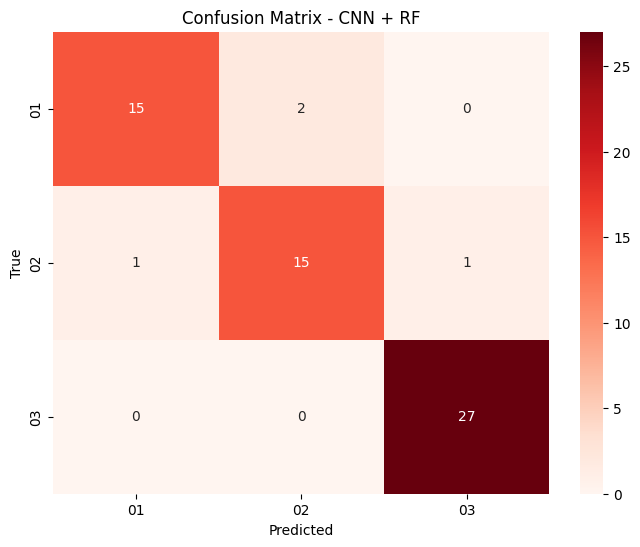

In [59]:
train_and_evaluate_classifier(rf, features_train, y_train_encoded, features_test, y_test_encoded, label_encoder.classes_, "CNN + RF")

CNN + XGB Accuracy: 0.93


Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.88      0.88        17
           1       0.88      0.88      0.88        17
           2       1.00      1.00      1.00        27

    accuracy                           0.93        61
   macro avg       0.92      0.92      0.92        61
weighted avg       0.93      0.93      0.93        61



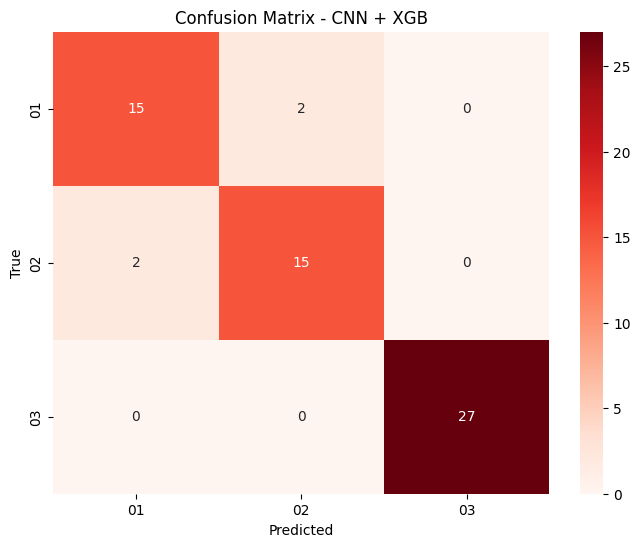

In [60]:
train_and_evaluate_classifier(xgb, features_train, y_train_encoded, features_test, y_test_encoded, label_encoder.classes_, "CNN + XGB")

CNN + SVM Accuracy: 0.92


Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.88      0.88        17
           1       0.83      0.88      0.86        17
           2       1.00      0.96      0.98        27

    accuracy                           0.92        61
   macro avg       0.91      0.91      0.91        61
weighted avg       0.92      0.92      0.92        61



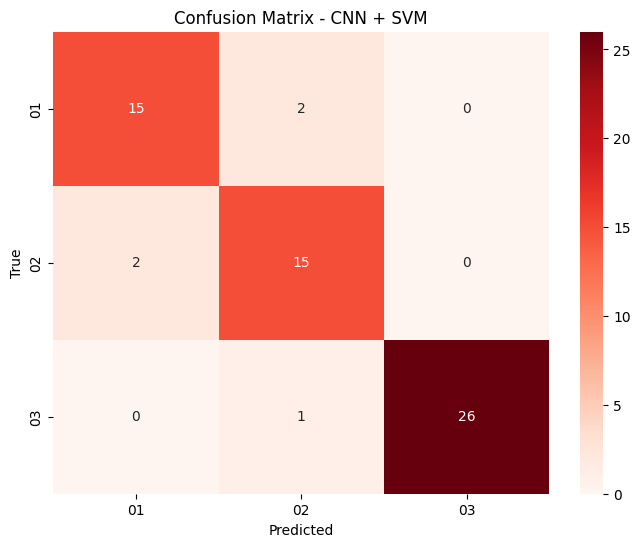

In [61]:
train_and_evaluate_classifier(svm, features_train, y_train_encoded, features_test, y_test_encoded, label_encoder.classes_, "CNN + SVM")

CNN + LOR Accuracy: 0.92


Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.82      0.88        17
           1       0.80      0.94      0.86        17
           2       1.00      0.96      0.98        27

    accuracy                           0.92        61
   macro avg       0.91      0.91      0.91        61
weighted avg       0.93      0.92      0.92        61



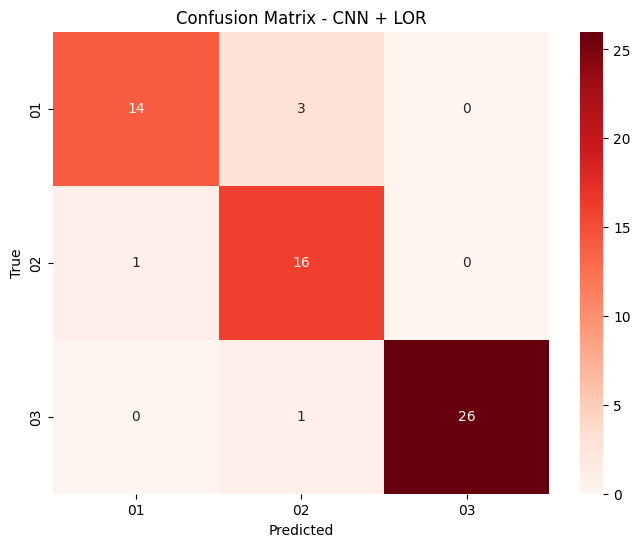

In [62]:
train_and_evaluate_classifier(lor, features_train, y_train_encoded, features_test, y_test_encoded, label_encoder.classes_, "CNN + LOR")

CNN + Ensemble Accuracy: 0.95


Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.88      0.91        17
           1       0.89      0.94      0.91        17
           2       1.00      1.00      1.00        27

    accuracy                           0.95        61
   macro avg       0.94      0.94      0.94        61
weighted avg       0.95      0.95      0.95        61



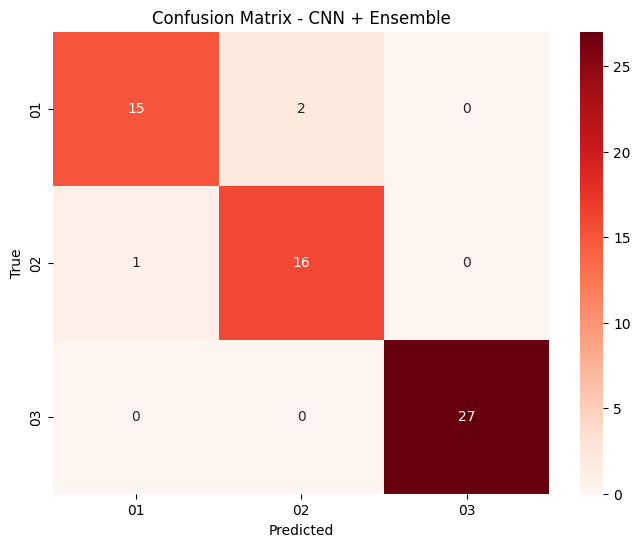

In [63]:
train_and_evaluate_classifier(ensemble, features_train, y_train_encoded, features_test, y_test_encoded, label_encoder.classes_, "CNN + Ensemble")

# Summarizing

> Summery the performances of all models

In [64]:
df_results = pd.DataFrame(results)
print("\nSummary of All Model Performances:\n")
print(df_results.sort_values(by='F1-score', ascending=False).to_string(index=False))


Summary of All Model Performances:

         Model  Accuracy  Precision  Recall  F1-score
CNN + Ensemble    0.9508     0.9421  0.9412    0.9411
      CNN + RF    0.9344     0.9280  0.9216    0.9244
     CNN + XGB    0.9344     0.9216  0.9216    0.9216
     CNN + LOR    0.9180     0.9111  0.9092    0.9070
     CNN + SVM    0.9180     0.9052  0.9092    0.9069


### Predicting

> Perform prediction on the Ensemble model

In [34]:
def pred(predicted_labels, predicted_folder_names, name):
  print("--"*10, name, "--"*10)
  mistakes = 0
  for i, (image, true_folder) in enumerate(test_images):
      if predicted_folder_names[i] != true_folder:
          mistakes += 1
          print(f"Image: {os.path.basename(image.filename):<20} True Folder: {true_folder:<10} Predicted Folder: {predicted_folder_names[i]}")
  print(f"\nMistakes: {mistakes} out of {len(test_images)}")
  print(f"Accuracy: {(len(test_images) - mistakes) / len(test_images):.2f}")

In [69]:
predicted_labels = ensemble.predict(features_test)
predicted_folder_names = label_encoder.inverse_transform(predicted_labels)

pred(predicted_labels, predicted_folder_names , "Ensemble")

-------------------- Ensemble --------------------
Image: 037.jpeg             True Folder: 01         Predicted Folder: 02
Image: 055.jpeg             True Folder: 02         Predicted Folder: 01
Image: 082.jpeg             True Folder: 01         Predicted Folder: 02

Mistakes: 3 out of 61
Accuracy: 0.95


### Saving

> Save all the models to Google Drive

In [36]:
model_folder_id = '1x4b4X-meKrRaD5CrXzjUsabrH0OxKvql'
ml_models = [('lor', lor), ('rf', rf), ('xgb', xgb), ('svm', svm), ('ensemble', ensemble)]

for name, model in ml_models:
    model_filename = f'{name}.pkl'
    joblib.dump(model, model_filename)
    gfile = drive.CreateFile({
        'title': model_filename,
        'parents': [{'id': model_folder_id}]
    })
    gfile.SetContentFile(model_filename)
    gfile.Upload()

    print(f'✅ {model_filename} uploaded to Google Drive')

✅ lor.pkl uploaded to Google Drive
✅ rf.pkl uploaded to Google Drive
✅ xgb.pkl uploaded to Google Drive
✅ svm.pkl uploaded to Google Drive
✅ ensemble.pkl uploaded to Google Drive


### Loading

> Load the Ensemble from Google Drive and Perform prediction

In [66]:
file_list = drive.ListFile({'q': f"'{model_folder_id}' in parents and trashed=false"}).GetList()
model_filename = "ensemble.pkl"

for file in file_list:
    if file['title'] == model_filename:
        file.GetContentFile(model_filename)
        print(f"Downloaded {model_filename} successfully!")
        break
else:
    raise ValueError(f"File '{model_filename}' was not found in folder ID {model_folder_id}.")

loaded_model = joblib.load(model_filename)
print("Model loaded successfully!")

Downloaded ensemble.pkl successfully!
Model loaded successfully!


In [74]:
predicted_labels = loaded_model.predict(features_test)
predicted_folder_names = label_encoder.inverse_transform(predicted_labels)
pred(predicted_labels, predicted_folder_names , "Ensemble")

-------------------- Ensemble --------------------
Image: 037.jpeg             True Folder: 01         Predicted Folder: 02
Image: 055.jpeg             True Folder: 02         Predicted Folder: 01
Image: 082.jpeg             True Folder: 01         Predicted Folder: 02

Mistakes: 3 out of 61
Accuracy: 0.95
